<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/Data_augmentation_to_address_overfitting_(Flower_Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt # For plotting graphs
import numpy as np # For numerical operations
import cv2 # For OpenCV computer vision tasks
import os # For interacting with the operating system
import PIL # For Python Imaging Library (image processing)
import tensorflow as tf # For TensorFlow deep learning framework

# Import specific modules from Keras (part of TensorFlow for building neural networks)
from tensorflow import keras
from tensorflow.keras import layers # For defining neural network layers
from tensorflow.keras.models import Sequential # For creating sequential models

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

In [4]:
data_dir

'/root/.keras/datasets/flower_photos'

In [5]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir = data_dir / 'flower_photos'
data_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [6]:
list(data_dir.glob('*/*.jpg'))

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/3991962484_085ba2da94.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/8223949_2928d3f6f6_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/8223968_6b51555d2f_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/4635296297_9ce69e4a6e.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/2465573725_d78caca9d4_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/8935477500_89f22cca03_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/16510864164_3afa8ac37f.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/19004688463_12a8423109.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/4573886524_5161482ca7_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/4557781241_00

In [7]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [8]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3909587261_f8cd3e7fe7.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/21522100663_455b77a90c_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/9458445402_79e4dfa89c.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/1813435848_7852708394_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/14597445311_8acb60247e.jpg')]

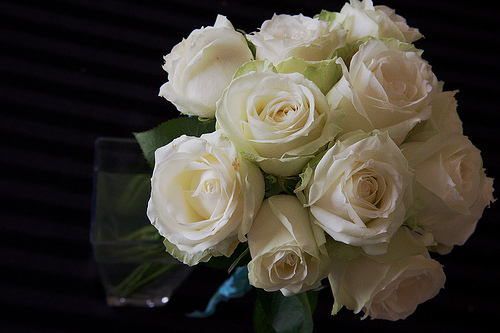

In [9]:
PIL.Image.open(str(roses[0]))

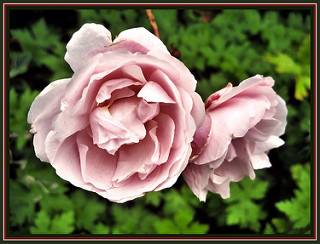

In [10]:
PIL.Image.open(str(roses[3]))

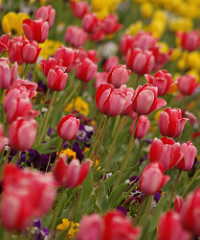

In [11]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [12]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [13]:
flowers_images_dict['roses']

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3909587261_f8cd3e7fe7.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/21522100663_455b77a90c_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/9458445402_79e4dfa89c.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/1813435848_7852708394_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/14597445311_8acb60247e.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/6125332325_b768e08bd9_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/5602220566_5cdde8fa6c_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/4243078361_7b92a932cd_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2491600761_7e9d6776e8_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/1801614110_bb9fa46830.jpg'),
 PosixPath('/roo

In [14]:
flowers_images_dict['dandelion']

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/3991962484_085ba2da94.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/8223949_2928d3f6f6_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/8223968_6b51555d2f_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/4635296297_9ce69e4a6e.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/2465573725_d78caca9d4_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/8935477500_89f22cca03_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/16510864164_3afa8ac37f.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/19004688463_12a8423109.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/4573886524_5161482ca7_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion/4557781241_00

In [15]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [16]:
str(flowers_images_dict['roses'][0])

'/root/.keras/datasets/flower_photos/flower_photos/roses/3909587261_f8cd3e7fe7.jpg'

array([[[ 9,  3,  4],
        [ 7,  1,  2],
        [ 6,  1,  2],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 1,  1,  1]],

       [[ 8,  3,  4],
        [ 8,  3,  4],
        [ 8,  3,  5],
        ...,
        [ 0,  0,  0],
        [ 1,  1,  1],
        [ 1,  1,  1]],

       [[ 8,  3,  4],
        [ 9,  4,  5],
        [10,  5,  7],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  1],
        [ 1,  1,  1]],

       ...,

       [[ 7,  5,  5],
        [ 7,  2,  4],
        [10,  4,  9],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  1],
        [ 1,  1,  1]],

       [[ 7,  5,  5],
        [ 6,  3,  5],
        [ 8,  4,  9],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  1],
        [ 1,  1,  1]],

       [[10,  4,  5],
        [ 7,  4,  6],
        [ 9,  5, 10],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], dtype=uint8)
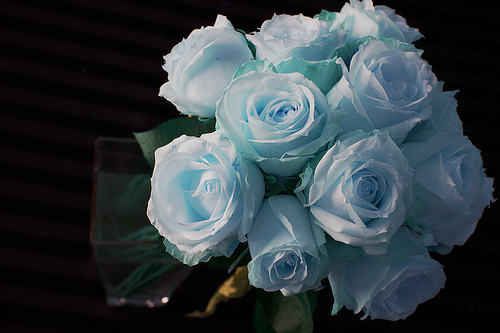

In [17]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img

In [18]:
img.shape

(333, 500, 3)

In [19]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [20]:
x, y = [], []
for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, (180, 180))
        x.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [21]:
y[:5]

[0, 0, 0, 0, 0]

array([[[ 7,  2,  3],
        [ 8,  3,  5],
        [ 5,  1,  3],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  2],
        [ 1,  1,  1]],

       [[ 9,  4,  5],
        [ 9,  3,  8],
        [ 9,  3,  7],
        ...,
        [ 0,  0,  0],
        [ 1,  1,  1],
        [ 1,  1,  1]],

       [[10,  5,  7],
        [11,  5, 10],
        [10,  2,  6],
        ...,
        [ 0,  0,  0],
        [ 1,  1,  1],
        [ 0,  0,  0]],

       ...,

       [[10,  1,  2],
        [ 9,  3,  5],
        [10,  3,  5],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 8,  2,  4],
        [ 7,  4,  7],
        [10,  4,  7],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 1,  1,  1]],

       [[ 7,  4,  5],
        [ 8,  3,  6],
        [11,  4,  8],
        ...,
        [ 1,  1,  1],
        [ 1,  1,  1],
        [ 0,  0,  0]]], dtype=uint8)
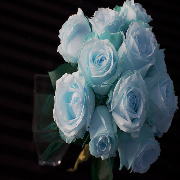

In [22]:
x[0]

In [23]:
x = np.array(x)
y = np.array(y)

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [25]:
len(x_train)

2752

In [26]:
len(x_test)

918

In [27]:
x_train_scaled = x_train / 255
x_test_scaled = x_test / 255

In [28]:
x_train_scaled[3]

array([[[0.50196078, 0.43529412, 0.44705882],
        [0.44313725, 0.41176471, 0.44705882],
        [0.14509804, 0.2       , 0.22352941],
        ...,
        [0.57254902, 0.58431373, 0.46666667],
        [0.60784314, 0.6       , 0.54117647],
        [0.46666667, 0.5372549 , 0.43529412]],

       [[0.24705882, 0.30196078, 0.25882353],
        [0.21568627, 0.3254902 , 0.27843137],
        [0.17647059, 0.27843137, 0.24705882],
        ...,
        [0.69411765, 0.66666667, 0.54901961],
        [0.61568627, 0.64705882, 0.56862745],
        [0.54509804, 0.58823529, 0.48235294]],

       [[0.29803922, 0.42745098, 0.34117647],
        [0.11372549, 0.32941176, 0.21960784],
        [0.14117647, 0.27058824, 0.19215686],
        ...,
        [0.63921569, 0.60784314, 0.49411765],
        [0.54117647, 0.57647059, 0.47843137],
        [0.54117647, 0.58823529, 0.4745098 ]],

       ...,

       [[0.08235294, 0.09803922, 0.15686275],
        [0.1254902 , 0.15294118, 0.22352941],
        [0.18823529, 0

In [29]:
num_classes = 5

model = Sequential([
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
             metrics=['accuracy'])

model.fit(x_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4586 - loss: 1.2603
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 80s 936ms/step - accuracy: 0.6210 - loss: 0.9721
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 947ms/step - accuracy: 0.7035 - loss: 0.7828
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7769 - loss: 0.5894
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 135s 935ms/step - accuracy: 0.8641 - loss: 0.3755


In [30]:
model.evaluate(x_test_scaled, y_test)


29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 297ms/step - accuracy: 0.6427 - loss: 1.0048


[1.004835605621338, 0.6427015066146851]

In [31]:
predictions = model.predict(x_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step


array([[ 0.95136964,  2.1856954 ,  0.99049604, -2.1393309 , -1.173363  ],
       [ 3.7152698 ,  0.20730004, -1.221597  , -2.6028433 ,  0.35768914],
       [ 0.6370807 ,  0.54330784,  0.9284494 , -0.5470696 ,  0.01782668],
       ...,
       [-0.92721087,  2.508395  ,  0.51591694,  3.7130806 , -0.4603419 ],
       [ 1.0368569 , -1.2605326 , -0.8004396 , -0.2563437 ,  2.2272658 ],
       [-0.10579158, -5.542559  ,  3.7882082 ,  9.284885  ,  4.380461  ]],
      dtype=float32)

In [32]:
score = tf.nn.softmax(predictions[1])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.93130904, 0.02789985, 0.00668405, 0.00167947, 0.03242762],
      dtype=float32)>

In [33]:
np.argmax(score)

np.int64(0)

In [34]:
y_test[1]

np.int64(0)

In [35]:
score = tf.nn.softmax(predictions[3])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([6.9831032e-01, 1.1638065e-03, 4.7966753e-04, 1.5615936e-03,
       2.9848459e-01], dtype=float32)>

In [36]:
np.argmax(score)


np.int64(0)

In [37]:
y_test[3]

np.int64(4)

In [38]:
data_augmentation = keras.Sequential([
    layers.RandomZoom(0.3),

])

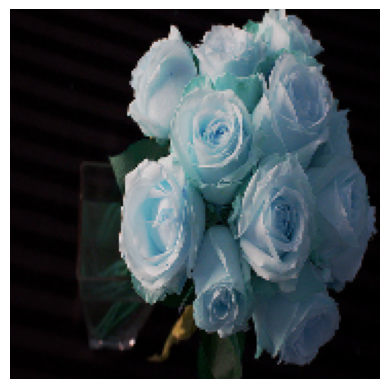

In [39]:
plt.axis('off')
plt.imshow(x[0])

In [40]:
data_augmentation(x)[0]

<tf.Tensor: shape=(180, 180, 3), dtype=float32, numpy=
array([[[ 1.996873  ,  1.        ,  1.1131861 ],
        [ 2.0227365 ,  0.5337906 ,  0.5337906 ],
        [ 1.8419703 ,  0.17840187,  0.53770447],
        ...,
        [ 3.756515  ,  2.2459836 ,  3.517327  ],
        [ 4.1973667 ,  2.3364315 ,  4.2294025 ],
        [ 5.226388  ,  2.3364315 ,  4.782916  ]],

       [[ 2.4705424 ,  1.        ,  1.        ],
        [ 2.2173512 ,  0.7511418 ,  0.7511418 ],
        [ 2.4843788 ,  0.60972023,  0.753231  ],
        ...,
        [ 3.264946  ,  1.6591284 ,  2.4084527 ],
        [ 3.818727  ,  1.5337906 ,  2.5698652 ],
        [ 4.090318  ,  1.6906426 ,  2.7582238 ]],

       [[ 3.725401  ,  1.2688522 ,  1.6281548 ],
        [ 3.0220833 ,  1.2688522 ,  1.412363  ],
        [ 2.9277184 ,  1.1965708 ,  1.2688522 ],
        ...,
        [ 2.3380098 ,  1.1965652 ,  1.5345826 ],
        [ 2.4622955 ,  1.        ,  1.3408624 ],
        [ 2.3067603 ,  1.2459881 ,  1.2459881 ]],

       ...,

     

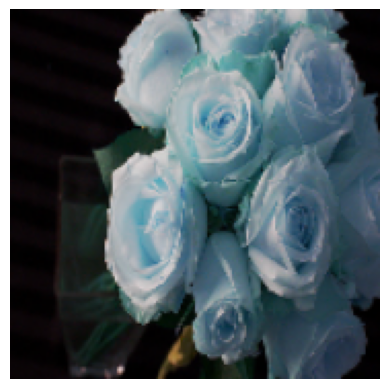

In [41]:
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype('uint8'))

In [42]:
data_augmentation = keras.Sequential([
    layers.RandomContrast(0.9),

])

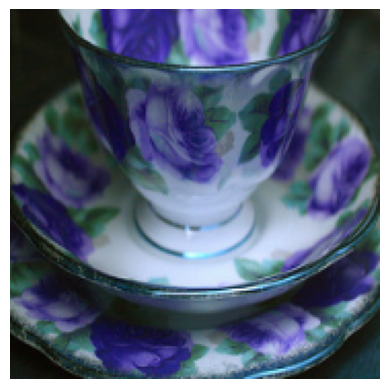

In [43]:
plt.axis('off')
plt.imshow(x[6])

In [ ]:
plt.axis('off')
plt.imshow(data_augmentation(x)[6].numpy().astype('uint8'))

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.9),

])

In [ ]:
plt.axis('off')
plt.imshow(x[4])

In [ ]:
plt.axis('off')
plt.imshow(data_augmentation(x)[4].numpy().astype('uint8'))

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal',
                      input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

])

In [ ]:
num_classes = 5

model = Sequential([
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
             metrics=['accuracy'])

model.fit(x_train_scaled, y_train, epochs=5)

In [ ]:
model.evaluate(x_test_scaled, y_test)